In [1]:
from pathlib import Path
from functools import reduce

import os
import glob
import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [2]:
# Load files

SP = Path("../data/synthetic_populations")
ELSA = Path("../data/imputed_elsa")
CONSTRAINTS = Path("../data/constraints")


SPEC_DIRS = {
    "full_specification": SP / "full_specification",
    "restricted_specification": SP / "restricted_specification",
    "drop_partnership": SP / "drop_partnership",
    "drop_nssec": SP / "drop_nssec",
    "drop_health": SP / "drop_health",
    "drop_ethnicity": SP / "drop_ethnicity",
    "drop_cob": SP / "drop_cob",

}

elsa = pd.read_csv(ELSA / "sms_imputed_m01.csv")
files = sorted(CONSTRAINTS.glob("*.csv"))
frames = []
for f in files:
    d = pd.read_csv(f)
    d = d.loc[:, ~d.columns.str.contains("^Unnamed")]
    frames.append(d.drop_duplicates(subset="area_code"))

cons = reduce(lambda l, r: pd.merge(l, r, on="area_code", how="outer"), frames)
cons.reset_index(inplace=True)


In [3]:
# Define constraints
constraints = {
    "age": [
        "age_65_69",
        "age_70_74",
        "age_75_79",
        "age_80_84",
        "age_85_plus",
    ],
 
    "sex": [
        "male",
        "female",
    ],
 
    "partnership": [
        "partner_has_partner",
        "partner_does_not_have_partner",
    ],
 
    "nssec": [
        "nssec_managerial",
        "nssec_intermediate",
        "nssec_manual",
    ],
 
    "country_of_birth": [
        "uk_born",
        "non_uk_born",
    ],
 
    "health": [
        "health_very_good_health",
        "health_good_health",
        "health_fair_health",
        "health_bad_health",
    ],
 
    "ethnicity": [
        "ethnicity_white",
        "ethnicity_non_white",
    ],
}
ALL_VARS = [v for vs in constraints.values() for v in vs]

SPECS = {
    "full_specification":       [],
    "restricted_specification": ["nationality", "ethnicity"],
    "drop_partnership":         ["partnership"],
    "drop_nssec":               ["nssec"],
    "drop_health":              ["health"],
    "drop_ethnicity":           ["ethnicity"],
    "drop_cob":                 ["country_of_birth"],

}

cons[ALL_VARS] = cons[ALL_VARS].mul(cons["population_65plus"], axis=0)
 
keep = pd.Series(True, index=elsa.index)
for vs in constraints.values():
    keep &= elsa[vs].sum(axis=1) == 1
donor = elsa.loc[keep].reset_index(drop=True)
 
tgt = cons.set_index("area_code")
area_name = cons.set_index("area_code")["area_name"]

In [4]:
# Internal validation with all specifications

fit_all = []
per_area_all = []
summary_rows = []

for spec, excluded in SPECS.items():

    kept = []
    for group, categories in constraints.items():
        if group not in excluded:
            kept += categories

    pop = pd.read_csv(SPEC_DIRS[spec] / "simulation_m01.csv")
    pop = pop.rename(columns={"area": "area_code"})
    pop = pop.merge(elsa[["idauniq"] + kept], on="idauniq", how="left")

    checks = []
    for la, people in pop.groupby("area_code"):
        weights = people["weight"].values
        for var in kept:
            achieved = (weights * people[var].values).sum()
            target = tgt.loc[la, var]
            checks.append({"specification": spec,
                           "area_code": la,
                           "variable": var,
                           "target": target,
                           "achieved": achieved,
                           "error": achieved - target})

    checks = pd.DataFrame(checks)
    checks["rel_error"] = checks["error"].abs() / checks["target"]

    by_area = []
    for la, cells in checks.groupby("area_code"):
        error = cells["error"].values
        rmse = np.sqrt((error ** 2).mean())
        by_area.append({"specification": spec,
                        "area_code": la,
                        "area_name": area_name.get(la),
                        "TAE": np.abs(error).sum(),
                        "RMSE": rmse,
                        "NRMSE": rmse / cells["target"].mean(),
                        "r": cells["target"].corr(cells["achieved"]),
                        "max_rel_pct": cells["rel_error"].max() * 100})

    by_area = pd.DataFrame(by_area)

    summary_rows.append({"specification": spec,
                         "n_cat": len(kept),
                         "TAE": by_area["TAE"].mean(),
                         "NRMSE_e5": by_area["NRMSE"].mean() * 1e5,
                         "r_min": by_area["r"].min(),
                         "max_rel_pct": checks["rel_error"].max() * 100})

    fit_all.append(checks)
    per_area_all.append(by_area)

In [5]:
val = pd.DataFrame(summary_rows)
print("\n" + val.to_string(index=False, float_format=lambda x: f"{x:.3f}"))


           specification  n_cat       TAE  NRMSE_e5  r_min  max_rel_pct
      full_specification     20     1.977     1.814  1.000        0.229
restricted_specification     18 14766.667 13250.829  0.321      740.392
        drop_partnership     18     1.674     1.787  1.000        0.229
              drop_nssec     17     1.296     1.368  1.000        0.212
             drop_health     16     1.574     1.662  1.000        0.229
          drop_ethnicity     18     1.851     1.975  1.000        0.229
                drop_cob     18     1.835     1.967  1.000        0.229


In [6]:
rows = []

for name in SPECS:
    sim = pd.read_csv(sorted(SPEC_DIRS[name].glob("simulation_m01*"))[0])

    prev = []
    ess = []
    for area, g in sim.groupby("area"):
        v = g["weight"].values
        prev.append(1000 * (v * g["has_any_care_needs"].values).sum() / v.sum())
        ess.append(100 * v.sum() ** 2 / (v ** 2).sum() / len(elsa))

    rows.append({"specification": name,
                 "prevalence": np.mean(prev),
                 "ESS_pct": np.mean(ess)})

print(pd.DataFrame(rows).to_string(index=False, float_format=lambda x: f"{x:.1f}"))

           specification  prevalence  ESS_pct
      full_specification       384.7     64.7
restricted_specification       385.0     77.3
        drop_partnership       380.7     66.9
              drop_nssec       383.0     69.2
             drop_health       346.8     69.8
          drop_ethnicity       384.7     67.5
                drop_cob       384.2     67.5


In [7]:
# Calculate differences between two specifications

by_spec = {}
for spec in ["full_specification", "restricted_specification"]:
    pop = pd.read_csv(SPEC_DIRS[spec] / "simulation_m01.csv")
    areas = []
    for la, people in pop.groupby("area"):
        weights = people["weight"].values
        ranked = np.sort(weights)[::-1]
        n_top = int(round(0.05 * len(ranked)))
        areas.append({"area_code": la,
                      "prevalence": 1000 * (weights * people["has_any_care_needs"].values).sum() / weights.sum(),
                      "population": weights.sum(),
                      "ess": weights.sum() ** 2 / (weights ** 2).sum(),
                      "top5_n": n_top,
                      "top5_share": ranked[:n_top].sum() / ranked.sum(),
                      "top5_mean_weight": ranked[:n_top].mean()})
    by_spec[spec] = pd.DataFrame(areas)

comparison = by_spec["full_specification"].merge(by_spec["restricted_specification"],
                                                 on="area_code", suffixes=("_full", "_restr"))
comparison = comparison.merge(cons[["area_code", "area_name"]], on="area_code")
comparison["gap"] = comparison["prevalence_restr"] - comparison["prevalence_full"]
comparison["gap_pct"] = 100 * comparison["gap"] / comparison["prevalence_full"]

mean_gap = comparison["gap"].abs().mean()

print("r                    :", round(comparison["prevalence_full"].corr(comparison["prevalence_restr"]), 3))
print("mean |diff| per 1,000:", round(mean_gap, 2))
print("as % of mean estimate:", round(100 * mean_gap / comparison["prevalence_full"].mean(), 2))

print("\nlargest relative differences:")
largest = comparison.reindex(comparison["gap_pct"].abs().sort_values(ascending=False).index).head(5)
print(largest[["area_name", "prevalence_full", "prevalence_restr", "gap", "gap_pct"]].to_string(
      index=False, float_format=lambda x: f"{x:.2f}"))

newham = comparison[comparison["area_name"].str.contains("Newham", case=False, na=False)].iloc[0]
print(f"\nNewham: pop 65+ {newham['population_full']:,.0f}")
print(f"  equal weighting : {newham['population_full'] / len(elsa):.1f} residents per respondent")
print(f"  top 5%          : {newham['top5_n_full']:.0f} respondents = "
      f"{100 * newham['top5_share_full']:.1f}% of population, "
      f"mean weight {newham['top5_mean_weight_full']:.1f}")
print(f"  ESS             : {newham['ess_full']:.0f} = {100 * newham['ess_full'] / len(elsa):.1f}%")

shares = cons[["area_code"]].copy()
shares["born_outside_uk"] = cons["non_uk_born"] / cons[["uk_born", "non_uk_born"]].sum(axis=1)
shares["non_white"] = cons["ethnicity_non_white"] / cons[["ethnicity_white", "ethnicity_non_white"]].sum(axis=1)

composition = comparison.merge(shares, on="area_code")
print()
for label, column in [("full      ", "ess_full"), ("restricted", "ess_restr")]:
    print(f"{label} ESS vs % born outside UK r = {composition[column].corr(composition['born_outside_uk']):.2f}"
          f" | vs % non-White r = {composition[column].corr(composition['non_white']):.2f}")

r                    : 0.989
mean |diff| per 1,000: 2.93
as % of mean estimate: 0.76

largest relative differences:
area_name  prevalence_full  prevalence_restr   gap  gap_pct
    Brent           382.08            403.40 21.32     5.58
   Harrow           363.69            377.23 13.54     3.72
   Newham           425.62            440.39 14.78     3.47
   Ealing           379.19            391.31 12.11     3.19
  Enfield           384.08            394.11 10.03     2.61

Newham: pop 65+ 25,166
  equal weighting : 5.0 residents per respondent
  top 5%          : 250 respondents = 59.5% of population, mean weight 59.9
  ESS             : 474 = 9.5%

full       ESS vs % born outside UK r = -0.82 | vs % non-White r = -0.86
restricted ESS vs % born outside UK r = -0.35 | vs % non-White r = -0.42


In [12]:
# Create figure

FONT_FAMILY = "Arial"
BACKGROUND = "#F5F5F5"
TEXT = "#333333"
SECONDARY_TEXT = "#555555"
GRID = "#D0D0D0"

ELSA_COLOUR = "#D9D9D9"                                    
AUTHORITY_COLOURS = ["#8DD3C7", "#FB8072", "#80B1D3",      
                     "#FDB462", "#B3DE69"]                
GENERAL_FONT_SIZE = 14
TICK_FONT_SIZE = 13
AXIS_LABEL_FONT_SIZE = 15
LEGEND_FONT_SIZE = 13

mpl.rcParams.update({
    "font.family": FONT_FAMILY,
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": GENERAL_FONT_SIZE,
    "text.color": TEXT,
    "axes.labelsize": AXIS_LABEL_FONT_SIZE,
    "axes.labelcolor": TEXT,
    "xtick.labelsize": TICK_FONT_SIZE,
    "ytick.labelsize": TICK_FONT_SIZE,
    "xtick.color": SECONDARY_TEXT,
    "ytick.color": TEXT,
    "legend.fontsize": LEGEND_FONT_SIZE,
    "figure.facecolor": BACKGROUND,
    "axes.facecolor": BACKGROUND,
    "savefig.facecolor": BACKGROUND,
    "savefig.transparent": False,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

LABELS = {
    "age_65_69": "Aged 65–69",
    "age_70_74": "Aged 70–74",
    "age_75_79": "Aged 75–79",
    "age_80_84": "Aged 80–84",
    "age_85_plus": "Aged 85+",
    "female": "Female",
    "partner_does_not_have_partner": "No partner",
    "nssec_managerial": "Managerial",
    "nssec_intermediate": "Intermediate",
    "nssec_manual": "Manual",
    "non_uk_born": "Born outside the UK",
    "health_fair_health": "Fair health",
    "health_bad_health": "Poor health",
    "ethnicity_non_white": "Non-White ethnic group",
}
ORDER = list(LABELS)

elsa_v = elsa[ORDER].mean().to_numpy() * 100


share = cons[["area_code", "area_name"]].copy()
for grp, vs in constraints.items():
    group_total = cons[vs].sum(axis=1)
    for v in vs:
        share[v] = 100 * cons[v] / group_total

div = share.merge(cmp[["area_code", "ess_full"]], on="area_code")
div = div.nsmallest(5, "ess_full").sort_values("ess_full").reset_index(drop=True)

print("five lowest-ESS authorities under the full specification:")
print(div[["area_name", "ess_full"]].to_string(index=False, float_format=lambda x: f"{x:.0f}"))

# common scale across the bars and the sticks
top = max(elsa_v.max(), div[ORDER].to_numpy(dtype=float).max())
axis_limit = max(10, float(np.ceil(top * 1.07 / 10) * 10))
axis_ticks = np.arange(0, axis_limit + 1, 10)

y = np.arange(len(ORDER))[::-1]
BAR_HEIGHT = 0.68
AUTHORITY_LINEWIDTH = 2.3

fig, ax = plt.subplots(figsize=(10.6, 8.0), dpi=300, facecolor=BACKGROUND)
ax.set_facecolor(BACKGROUND)

ax.barh(y, elsa_v, height=BAR_HEIGHT, color=ELSA_COLOUR, edgecolor="none", zorder=2)

for i, row in div.iterrows():
    values = row[ORDER].to_numpy(dtype=float)
    ax.vlines(values, y - BAR_HEIGHT / 2, y + BAR_HEIGHT / 2,
              colors=AUTHORITY_COLOURS[i], linewidth=AUTHORITY_LINEWIDTH, zorder=4)

ax.set_yticks(y)
ax.set_yticklabels([LABELS[v] for v in ORDER])
ax.set_xlim(0, axis_limit)
ax.set_xticks(axis_ticks)
ax.set_xticklabels([f"{t:.0f}%" for t in axis_ticks])
ax.set_xlabel("Share of population aged 65 and over", labelpad=14, color=TEXT)
ax.set_ylabel("")
ax.tick_params(axis="x", length=0, pad=7)
ax.tick_params(axis="y", length=0, pad=8)

ax.grid(axis="x", color=GRID, linewidth=0.8, alpha=0.85, zorder=0)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)

handles = [Patch(facecolor=ELSA_COLOUR, edgecolor="none")]
labels = [f"ELSA sample"]
for i, row in div.iterrows():
    handles.append(Line2D([0], [0], color=AUTHORITY_COLOURS[i],
                          linewidth=AUTHORITY_LINEWIDTH, solid_capstyle="butt"))
    labels.append(row["area_name"])

ax.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 1.075), ncol=3,
          frameon=False, fontsize=LEGEND_FONT_SIZE, handlelength=2.0, handleheight=1.2,
          handletextpad=0.6, columnspacing=2.1, borderaxespad=0)

fig.subplots_adjust(left=0.22, right=0.975, bottom=0.12, top=0.79)

fig.savefig("../figures/fig_elsa_composition_lowest_ess.pdf", bbox_inches="tight",
            facecolor=fig.get_facecolor())
fig.savefig("../figures/fig_elsa_composition_lowest_ess.png", dpi=300, bbox_inches="tight",
            facecolor=fig.get_facecolor())

for ext in ("pdf", "png"):
    fig.savefig(f"../figures/any_care_need_odds_ratios.{ext}", bbox_inches="tight", facecolor=BACKGROUND)
plt.show()

NameError: name 'cmp' is not defined

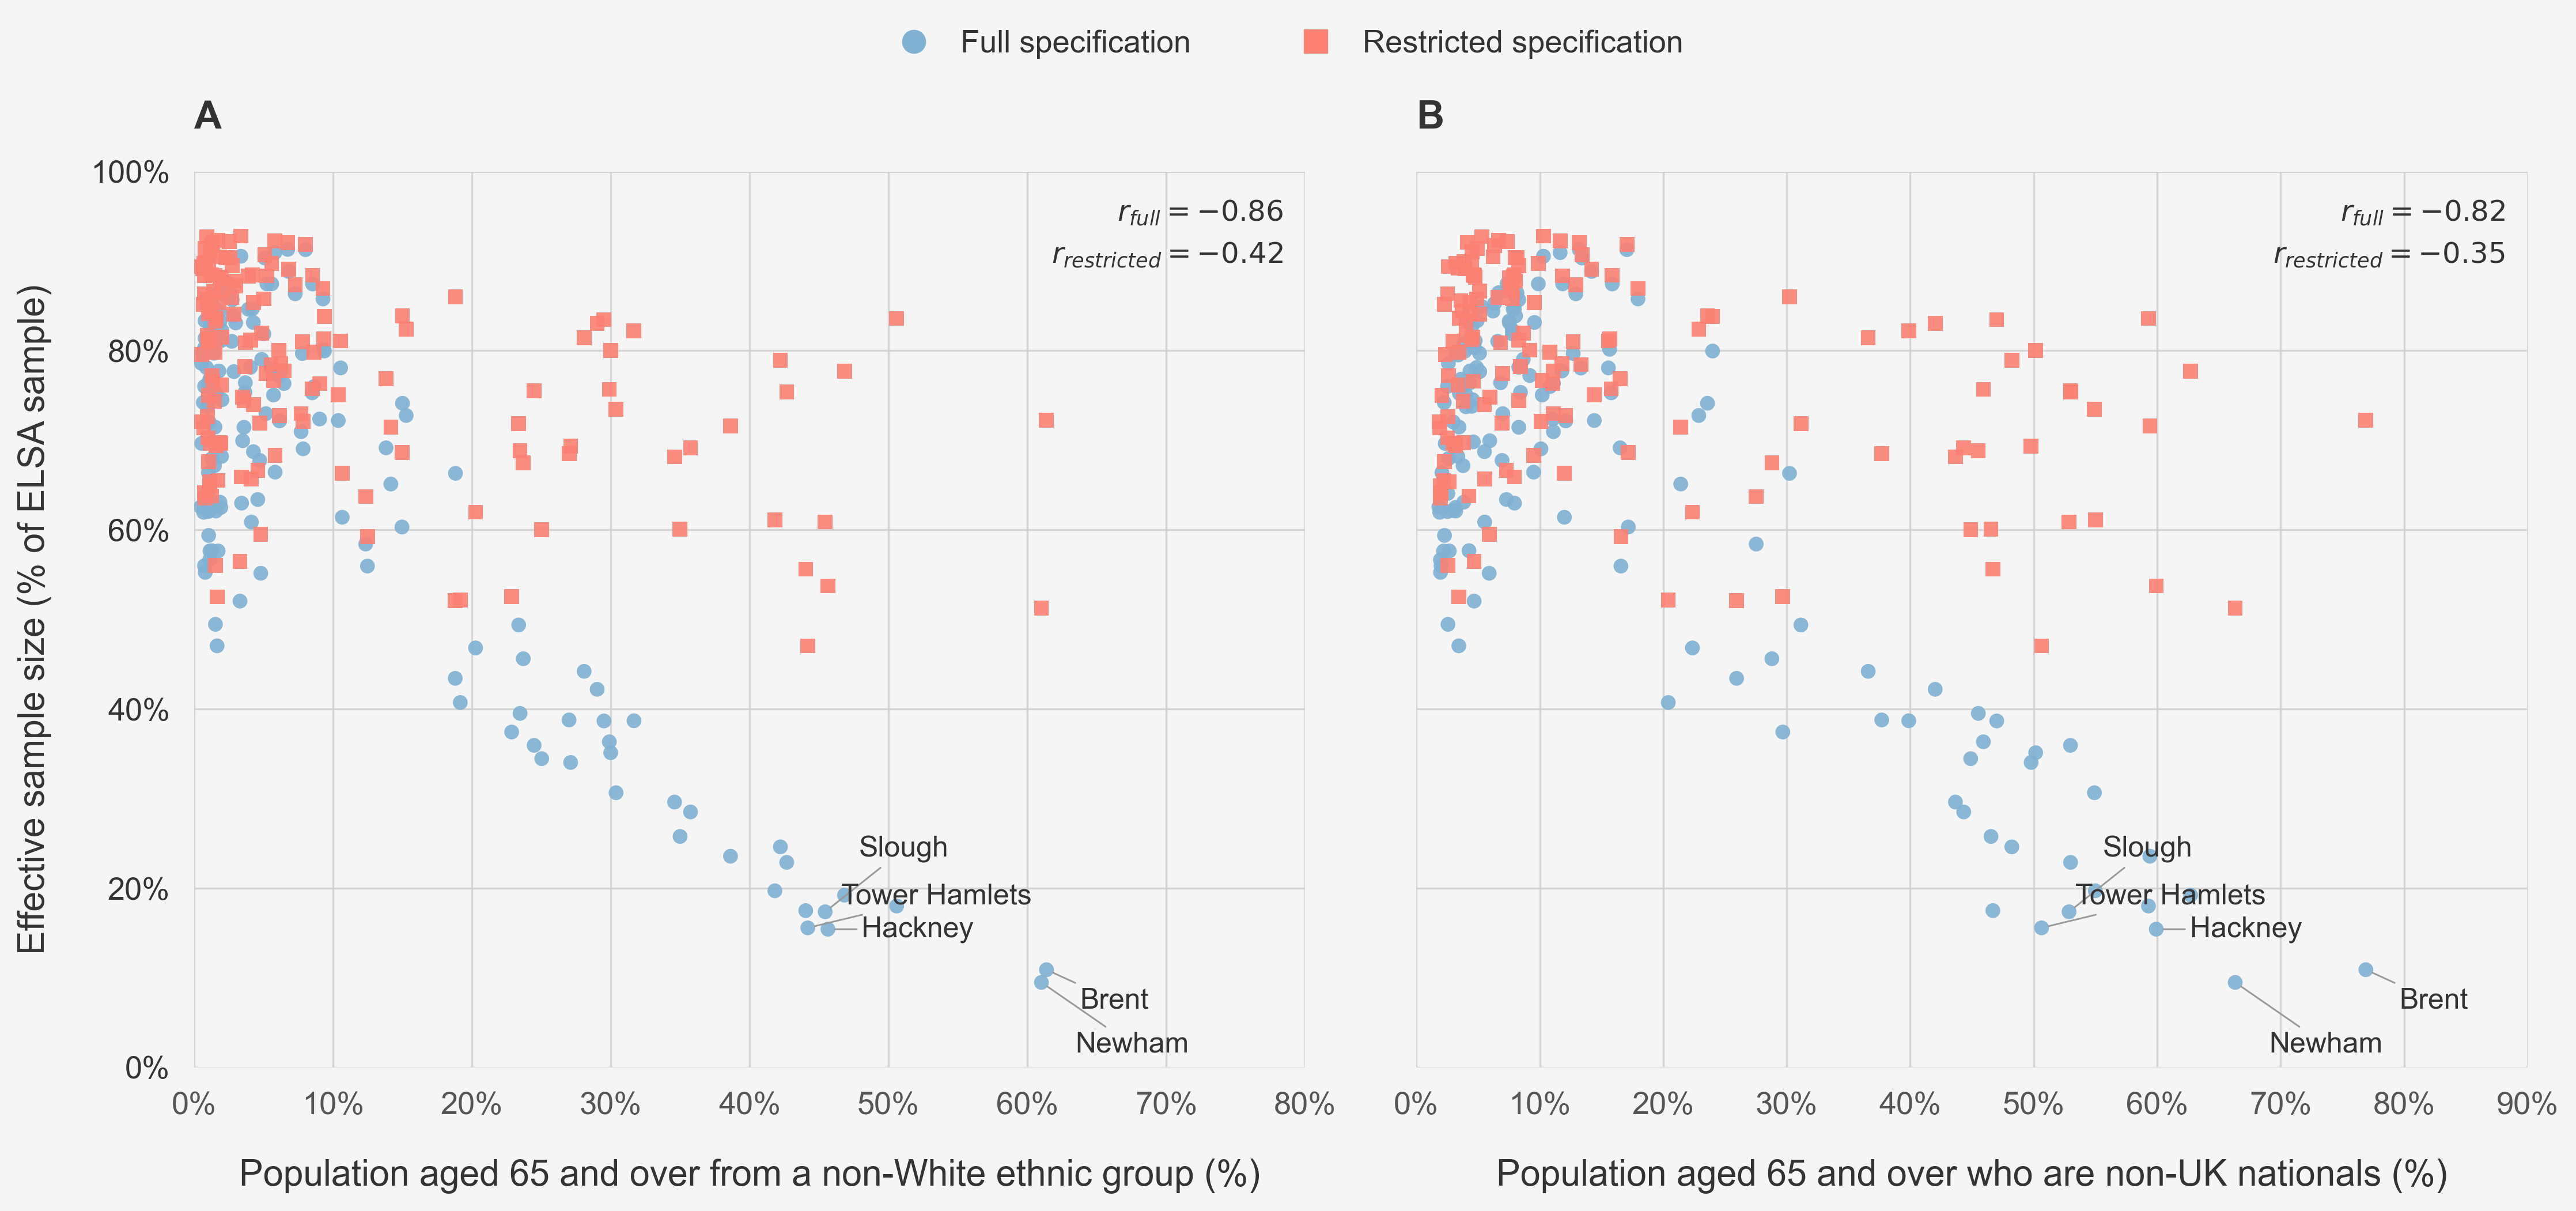

In [11]:
FULL_COLOUR = AUTHORITY_COLOURS[2]        # blue
RESTRICTED_COLOUR = AUTHORITY_COLOURS[1]  # coral

COLOURS = {"full": FULL_COLOUR, "restricted": RESTRICTED_COLOUR}
MARKERS = {"full": "o", "restricted": "s"}
SPECS_SHOWN = ["full", "restricted"]

PANELS = [("A", "non_white",
           "Population aged 65 and over from a non-White ethnic group (%)"),
          ("B", "born_outside_uk",
           "Population aged 65 and over who are non-UK nationals (%)")]

N_LABELLED = 5

ess = {"full": 100 * composition["ess_full"] / len(elsa),
       "restricted": 100 * composition["ess_restr"] / len(elsa)}

labelled = (composition
            .nsmallest(N_LABELLED, "ess_full")
            .sort_values("ess_full", ascending=False)["area_name"]
            .tolist())

fig, axes = plt.subplots(1, 2, figsize=(15.0, 7.0), dpi=300,
                         sharey=True, facecolor=BACKGROUND)

for ax, (letter, variable, xlabel) in zip(axes, PANELS):

    share = 100 * composition[variable]

    for spec in SPECS_SHOWN:
        ax.scatter(share, ess[spec], s=38, marker=MARKERS[spec],
                   color=COLOURS[spec], edgecolor="none", alpha=0.9, zorder=3)

    spread = np.linspace(26, -26, len(labelled))

    for offset, name in zip(spread, labelled):
        here = composition["area_name"] == name
        ax.annotate(name,
                    (share[here].iloc[0], ess["full"][here].iloc[0]),
                    xytext=(14, offset), textcoords="offset points",
                    fontsize=12, color=TEXT, ha="left", va="center", zorder=5,
                    arrowprops=dict(arrowstyle="-", color="#999999",
                                    linewidth=0.7, shrinkA=0, shrinkB=3))

    ax.set_facecolor(BACKGROUND)
    ax.set_xlabel(xlabel, fontsize=AXIS_LABEL_FONT_SIZE, labelpad=16, color=TEXT)
    ax.set_ylim(0, 100)
    ax.set_xlim(0, np.ceil(share.max() / 10) * 10 + 10)

    ax.xaxis.set_major_formatter(lambda v, pos: f"{v:.0f}%")
    ax.tick_params(axis="x", labelsize=TICK_FONT_SIZE, length=0, pad=10)
    ax.tick_params(axis="y", labelsize=TICK_FONT_SIZE, length=0, pad=10)

    ax.grid(color=GRID, linewidth=0.8, alpha=0.85, zorder=0)
    ax.set_axisbelow(True)

    for spine in ax.spines.values():
        spine.set_visible(False)

    # panel letter, top left
    ax.text(0.0, 1.04, letter, transform=ax.transAxes, ha="left", va="bottom",
            fontsize=16, fontweight="bold", color=TEXT)

    # correlations, top right
    note = (f"$r_{{full}} = {share.corr(ess['full']):.2f}$\n"
            f"$r_{{restricted}} = {share.corr(ess['restricted']):.2f}$")
    ax.text(0.98, 0.97, note, transform=ax.transAxes, ha="right", va="top",
            fontsize=12, color=TEXT, linespacing=1.6)

axes[0].set_ylabel("Effective sample size (% of ELSA sample)",
                   fontsize=AXIS_LABEL_FONT_SIZE, labelpad=16, color=TEXT)
axes[0].yaxis.set_major_formatter(lambda v, pos: f"{v:.0f}%")

handles = [Line2D([0], [0], marker=MARKERS[spec], linestyle="", markersize=9,
                  color=COLOURS[spec]) for spec in SPECS_SHOWN]

fig.legend(handles, ["Full specification", "Restricted specification"],
           loc="lower center", bbox_to_anchor=(0.5, 0.95), ncol=2,
           frameon=False, fontsize=LEGEND_FONT_SIZE,
           handletextpad=0.5, columnspacing=3.0)

fig.subplots_adjust(left=0.08, right=0.98, bottom=0.14, top=0.88, wspace=0.10)

fig.savefig("../figures/fig_ess_composition.pdf", bbox_inches="tight",
            facecolor=fig.get_facecolor(), transparent=False)
fig.savefig("../figures/fig_ess_composition.png", dpi=300, bbox_inches="tight",
            facecolor=fig.get_facecolor(), transparent=False)

plt.show()